# Step 4c: Decline Forecast — Classification, Timing & Slope

This notebook trains a **DeclineForecastModel** that observes process signals up to time T
(40–90% of a batch) and predicts three outputs:

- **`decline_prob`**: probability that the batch exhibits concentration decline (sigmoid)
- **`delta_t_break`**: normalized time until decline onset, `(t_break - T) / T_max`
- **`slope`**: decline rate in g/L/h (softplus, non-negative)

The model uses a PatchTST encoder with a multi-task head, trained with:
- BCE loss for decline classification
- MSE loss for delta timing (all samples)
- Log-space MSE for slope (declining batches only)

Decline labels come from pre-fitted piece-log parameters (slope > 0.01 → decline).

In [1]:
import sys
sys.path.insert(0, "..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from pathlib import Path

from src.data_loader import load_batches
from src.domain_splits import get_control_mode_split
from src.piecelog_model import fit_all_batches, PARAM_NAMES
from src.decline_forecast import DeclineForecastModel, initialize_decline_forecast_head
from src.decline_dataset import create_decline_dataloaders, T_MAX_NORM
from src.train_decline_forecast import train_and_evaluate_decline, eval_decline_epoch

device = torch.device(
    'cuda' if torch.cuda.is_available()
    else 'mps' if torch.backends.mps.is_available()
    else 'cpu'
)
print(f'Using device: {device}')

Using device: mps


## 1. Load Data & Domain Split

In [2]:
batches = load_batches()
split = get_control_mode_split("1c")

source_ids = split["source"]  # Batches 1-60 (recipe + operator)
target_ids = split["target"]  # Batches 61-90 (APC)

print(f"Source batches: {len(source_ids)}")
print(f"Target batches: {len(target_ids)}")

Source batches: 60
Target batches: 30


## 2. Pre-Fit Piece-Log Parameters

In [3]:
output_dir = Path("../outputs")
params_path = output_dir / "fitted_piecelog_params.csv"

if params_path.exists():
    fitted_params_df = pd.read_csv(params_path)
    print(f"Loaded cached fits: {len(fitted_params_df)} batches")
else:
    fitted_params_df = fit_all_batches(batches, exclude_faults=True)
    output_dir.mkdir(exist_ok=True)
    fitted_params_df.to_csv(params_path, index=False)
    print(f"Fitted {len(fitted_params_df)} batches")

print(f"R\u00b2 mean: {fitted_params_df['r_squared'].mean():.6f}")

Loaded cached fits: 90 batches
R² mean: 0.999647


## 3. Decline Statistics

Examine the distribution of decline vs non-decline batches, and the
t_break / slope distributions across source and target domains.

In [4]:
GATE_THRESHOLD = 0.01

fitted_params_df["has_decline"] = fitted_params_df["slope"] > GATE_THRESHOLD
fitted_params_df["domain"] = fitted_params_df["batch_id"].apply(
    lambda b: "Source" if b in source_ids else "Target"
)

print("Decline counts by domain:")
print(fitted_params_df.groupby("domain")["has_decline"].value_counts())
print()

# Summary stats for declining batches
declining = fitted_params_df[fitted_params_df["has_decline"]]
print(f"Declining batches: {len(declining)} / {len(fitted_params_df)}")
print(f"  t_break: mean={declining['t_break'].mean():.1f}h, std={declining['t_break'].std():.1f}h")
print(f"  slope:   mean={declining['slope'].mean():.4f}, std={declining['slope'].std():.4f}")

Decline counts by domain:
domain  has_decline
Source  True           35
        False          25
Target  False          30
Name: count, dtype: int64

Declining batches: 35 / 90
  t_break: mean=170.6h, std=27.9h
  slope:   mean=0.1240, std=0.0348


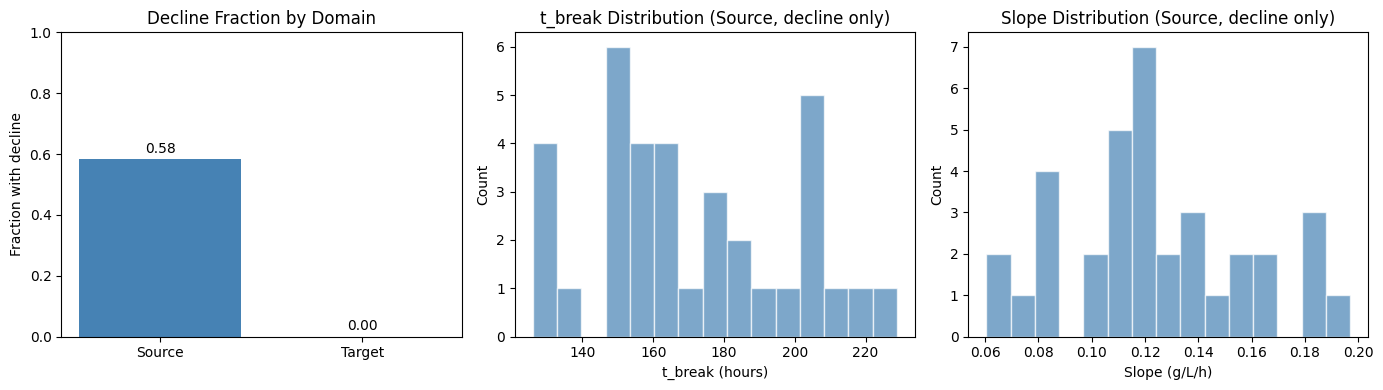

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Bar chart: decline fraction by domain
frac = fitted_params_df.groupby("domain")["has_decline"].mean()
axes[0].bar(frac.index, frac.values, color=["steelblue", "coral"])
axes[0].set_ylabel("Fraction with decline")
axes[0].set_title("Decline Fraction by Domain")
axes[0].set_ylim(0, 1)
for i, (dom, val) in enumerate(frac.items()):
    axes[0].text(i, val + 0.02, f"{val:.2f}", ha="center")

# t_break distribution (source declining only)
src_decline = fitted_params_df[
    (fitted_params_df["domain"] == "Source") & fitted_params_df["has_decline"]
]
axes[1].hist(src_decline["t_break"], bins=15, color="steelblue", alpha=0.7, edgecolor="white")
axes[1].set_xlabel("t_break (hours)")
axes[1].set_ylabel("Count")
axes[1].set_title("t_break Distribution (Source, decline only)")

# slope distribution (source declining only)
axes[2].hist(src_decline["slope"], bins=15, color="steelblue", alpha=0.7, edgecolor="white")
axes[2].set_xlabel("Slope (g/L/h)")
axes[2].set_ylabel("Count")
axes[2].set_title("Slope Distribution (Source, decline only)")

plt.tight_layout()
plt.show()

### Concentration Trajectories — Decline vs No-Decline

Show raw P concentration curves for 6 batches (3 declining, 3 non-declining)
with t_break marked. This gives visual context for what the model classifies.

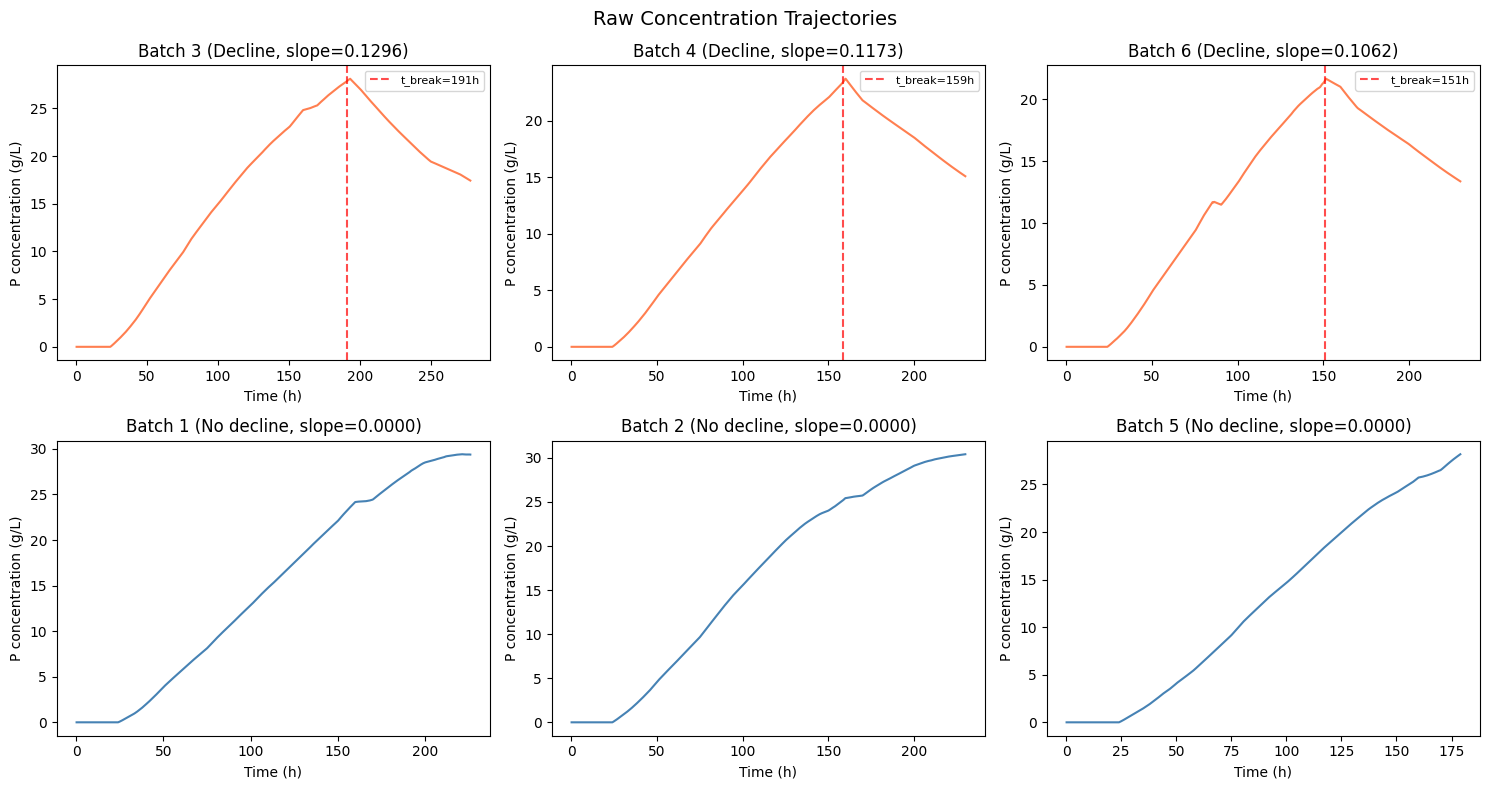

In [6]:
# Pick 3 declining + 3 non-declining source batches for visualization
src_params = fitted_params_df[fitted_params_df["batch_id"].isin(source_ids)]
decline_bids = src_params[src_params["has_decline"]]["batch_id"].tolist()[:3]
nodecline_bids = src_params[~src_params["has_decline"]]["batch_id"].tolist()[:3]
traj_bids = decline_bids + nodecline_bids

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, bid in zip(axes.flat, traj_bids):
    df = batches[bid]
    row = fitted_params_df[fitted_params_df["batch_id"] == bid].iloc[0]
    has_decline = row["slope"] > GATE_THRESHOLD

    ax.plot(df["time"], df["P"], lw=1.5,
            color="coral" if has_decline else "steelblue")
    if has_decline:
        ax.axvline(row["t_break"], color="red", ls="--", alpha=0.7, label=f"t_break={row['t_break']:.0f}h")
        ax.legend(fontsize=8)
    label = "Decline" if has_decline else "No decline"
    ax.set_title(f"Batch {bid} ({label}, slope={row['slope']:.4f})")
    ax.set_xlabel("Time (h)")
    ax.set_ylabel("P concentration (g/L)")

plt.suptitle("Raw Concentration Trajectories", fontsize=14)
plt.tight_layout()
plt.show()

## 4. Create DataLoaders

In [7]:
loaders = create_decline_dataloaders(
    source_ids=source_ids,
    target_ids=target_ids,
    fitted_params_df=fitted_params_df,
    batches=batches,
    batch_size=20,
    max_seq_len=1200,
    min_T_fraction=0.6,
    max_T_fraction=0.95,
    samples_per_batch=16,
    decline_oversample=3.0,
    seed=42,
)

print(f"Train samples: {len(loaders['train_dataset'])}")
print(f"Val samples:   {len(loaders['val_dataset'])}")
print(f"Target samples: {len(loaders['target_dataset'])}")
print(f"Input features: {loaders['n_features']}")
print(f"Sequence length: {loaders['max_seq_len']}")

Train samples: 768
Val samples:   192
Target samples: 480
Input features: 28
Sequence length: 1200


### Dataset Sample Diagnostic

Pull a sample from the training dataset and verify:
- Tensor shape and statistics (min/max/mean per channel)
- No NaN values remain after preprocessing
- Heatmap of the (seq_len, n_ch) input tensor to check for dead/flat channels

NaN check: 0 NaN values across 50 samples

Sample 0 — batch_id=58, T_frac=0.87
  x shape: torch.Size([1200, 28])
  x dtype: torch.float32
  NaN count: 0
  Global min=-4000.000, max=32.908, mean=-5.889

  Channel                        min      max     mean      std
  ------------------------------------------------------------
  Fg                          -3.058    0.837    0.010    0.974
  Fs                          -2.600    2.709   -0.219    0.842
  Fw                          -0.992    2.215   -0.064    0.946
  pressure                    -2.566    1.150    0.037    0.965
  Fpaa                        -2.093    0.780    0.003    0.909
  Foil                        -0.881    1.740    0.075    0.943
  Fa                           0.000    2.602    0.013    0.143
  Fh                          -0.009   32.908    1.216    3.219
  Fremoved                  -4000.000    0.000 -166.667  799.638
  Fb                          -1.425    3.783    0.007    0.915
  Fc                          

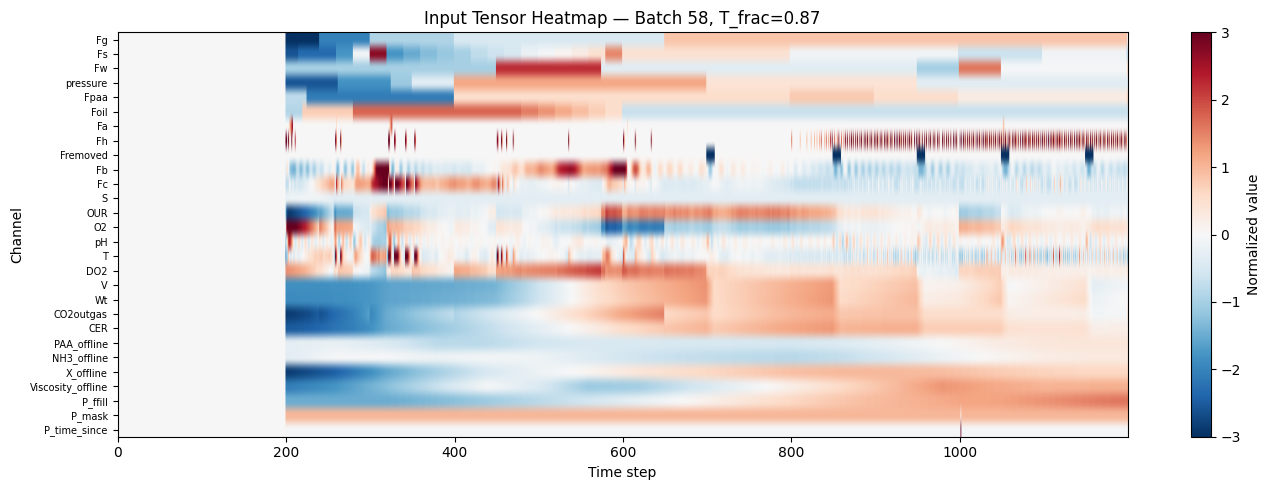

In [8]:
from src.feature_config import INPUT_FEATURES_EXPANDED

train_ds = loaders["train_dataset"]
feature_names = list(INPUT_FEATURES_EXPANDED) + ["P_ffill", "P_mask", "P_time_since"]

# Check multiple samples for NaN
n_check = min(50, len(train_ds))
nan_count = 0
for i in range(n_check):
    s = train_ds[i]
    nan_count += torch.isnan(s["x"]).sum().item()
print(f"NaN check: {nan_count} NaN values across {n_check} samples")

# Detailed look at one sample
sample = train_ds[0]
x = sample["x"]  # (seq_len, n_ch)
print(f"\nSample 0 — batch_id={train_ds.samples[0]['batch_id']}, T_frac={sample['T_frac']:.2f}")
print(f"  x shape: {x.shape}")
print(f"  x dtype: {x.dtype}")
print(f"  NaN count: {torch.isnan(x).sum().item()}")
print(f"  Global min={x.min():.3f}, max={x.max():.3f}, mean={x.mean():.3f}")

# Per-channel stats
print(f"\n  {'Channel':<25s} {'min':>8s} {'max':>8s} {'mean':>8s} {'std':>8s}")
print("  " + "-" * 60)
for ch_idx, name in enumerate(feature_names):
    ch = x[:, ch_idx]
    nonzero = ch[ch != 0]
    if len(nonzero) > 0:
        print(f"  {name:<25s} {ch.min():>8.3f} {ch.max():>8.3f} {ch.mean():>8.3f} {ch.std():>8.3f}")
    else:
        print(f"  {name:<25s}    (all zero)")

# Heatmap
fig, ax = plt.subplots(figsize=(14, 5))
im = ax.imshow(x.numpy().T, aspect="auto", cmap="RdBu_r", vmin=-3, vmax=3)
ax.set_xlabel("Time step")
ax.set_ylabel("Channel")
ax.set_yticks(range(len(feature_names)))
ax.set_yticklabels(feature_names, fontsize=7)
ax.set_title(f"Input Tensor Heatmap — Batch {train_ds.samples[0]['batch_id']}, T_frac={sample['T_frac']:.2f}")
plt.colorbar(im, ax=ax, label="Normalized value")
plt.tight_layout()
plt.show()

### Raw Signal Showcase

Plot 4 key process features (Temperature, pH, Dissolved O2, Substrate feed rate)
for 2 source batches, showing the raw time-series that the model ingests.

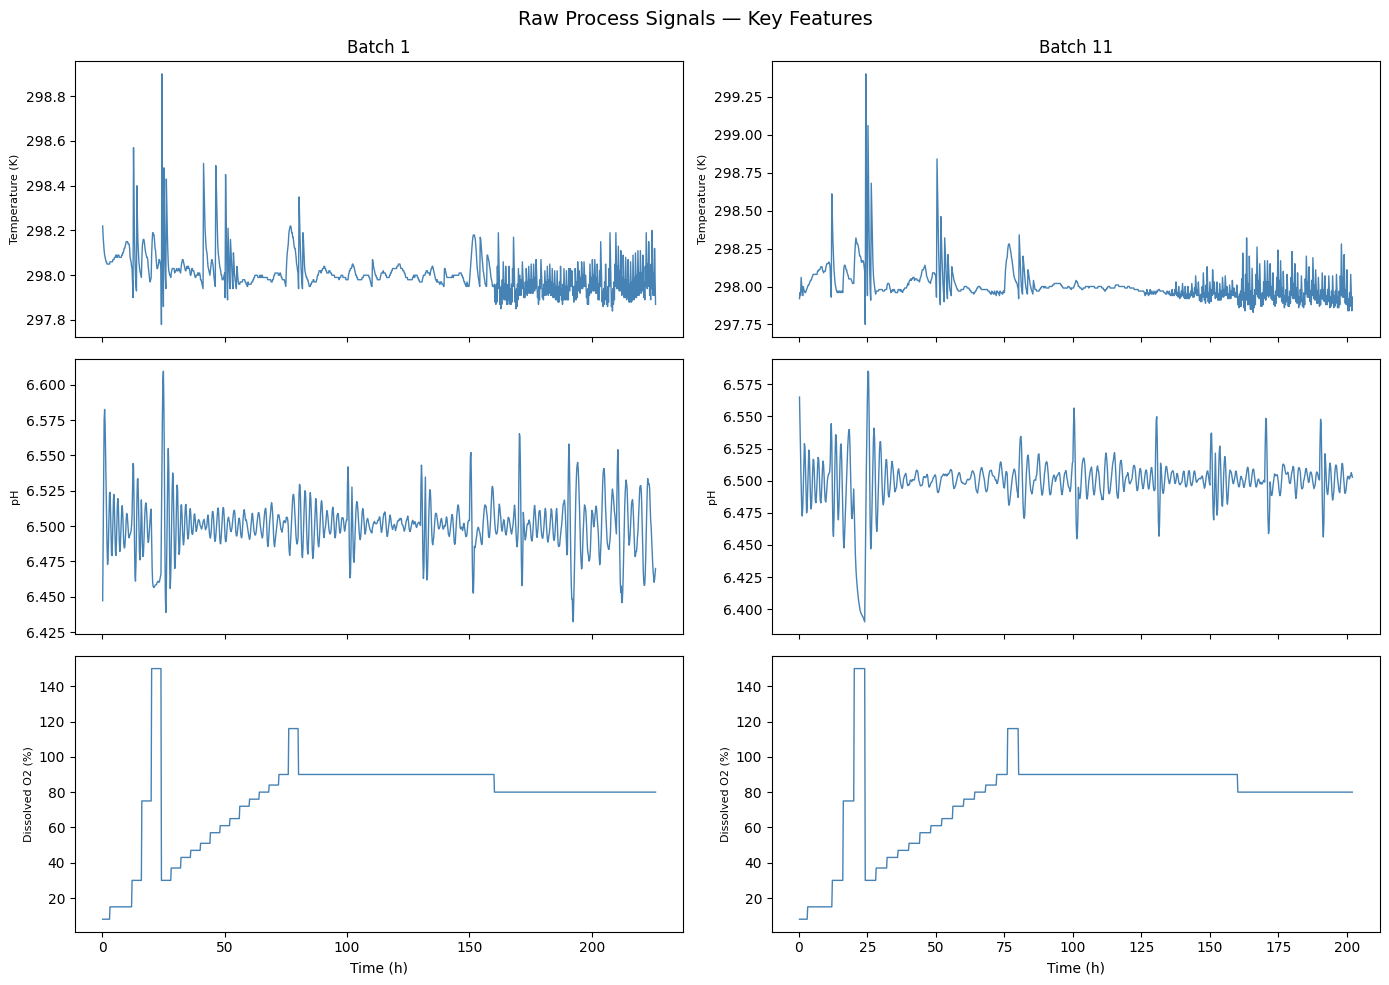

In [9]:
showcase_features = ["T", "pH", "Fs"]
showcase_labels = ["Temperature (K)", "pH", "Dissolved O2 (%)", "Substrate Feed (L/h)"]
showcase_bids = [source_ids[0], source_ids[10]]

fig, axes = plt.subplots(len(showcase_features), len(showcase_bids), figsize=(14, 10), sharex="col")
for col, bid in enumerate(showcase_bids):
    df = batches[bid]
    for row, (feat, label) in enumerate(zip(showcase_features, showcase_labels)):
        ax = axes[row, col]
        ax.plot(df["time"], df[feat], lw=1, color="steelblue")
        ax.set_ylabel(label, fontsize=8)
        if row == 0:
            ax.set_title(f"Batch {bid}")
        if row == len(showcase_features) - 1:
            ax.set_xlabel("Time (h)")

plt.suptitle("Raw Process Signals — Key Features", fontsize=14)
plt.tight_layout()
plt.show()

### T_frac Comparison — Same Batch at 0.4 vs 0.9

Verify that with `max_seq_len=1100`, both short and long observation windows
produce meaningful (non-flat) input tensors for the same batch.

/var/folders/s3/fkdq7lzx1bvdt4sqbz1dsg0c0000gp/T/ipykernel_85835/3947016196.py:44: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


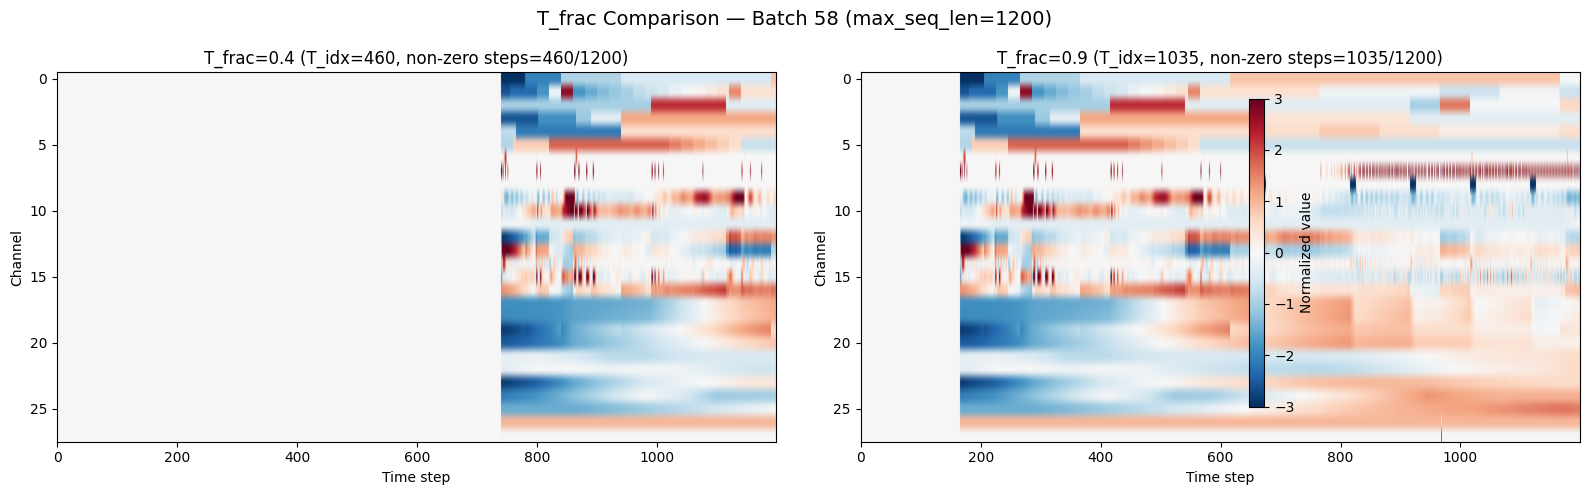

In [10]:
from src.preprocessing import preprocess_expanded_features, normalize_features_expanded
from src.tft_dataset import build_concentration_channels

compare_bid = train_ds.batch_ids[0]
compare_df = batches[compare_bid]
n_steps = len(compare_df)
max_sl = loaders["max_seq_len"]
stats = loaders["stats"]
features = list(INPUT_FEATURES_EXPANDED)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, tf in zip(axes, [0.4, 0.9]):
    T_idx = max(10, min(int(tf * n_steps), n_steps - 1))
    input_df = compare_df.iloc[:T_idx].copy()

    processed = preprocess_expanded_features(input_df, features)
    X_feat = normalize_features_expanded(processed, stats)
    X_feat = np.nan_to_num(X_feat, nan=0.0)

    conc_ffill, conc_mask, conc_time_since = build_concentration_channels(input_df, "P")
    conc_ffill_norm = (conc_ffill - train_ds.conc_mean) / train_ds.conc_std
    conc_time_norm = (conc_time_since - train_ds.time_since_mean) / train_ds.time_since_std

    X = np.concatenate([
        X_feat, conc_ffill_norm[:, None], conc_mask[:, None], conc_time_norm[:, None]
    ], axis=1)

    T_actual = X.shape[0]
    if T_actual > max_sl:
        X = X[T_actual - max_sl:]
    elif T_actual < max_sl:
        pad = np.zeros((max_sl - T_actual, X.shape[1]))
        X = np.concatenate([pad, X], axis=0)

    non_zero_steps = np.count_nonzero(np.abs(X).sum(axis=1))
    im = ax.imshow(X.T, aspect="auto", cmap="RdBu_r", vmin=-3, vmax=3)
    ax.set_title(f"T_frac={tf} (T_idx={T_idx}, non-zero steps={non_zero_steps}/{max_sl})")
    ax.set_xlabel("Time step")
    ax.set_ylabel("Channel")

plt.colorbar(im, ax=axes, label="Normalized value", shrink=0.8)
plt.suptitle(f"T_frac Comparison — Batch {compare_bid} (max_seq_len={max_sl})", fontsize=14)
plt.tight_layout()
plt.show()

/Users/aless/Desktop/Projects/IndPenSim_Forecast_UDA/notebooks/../src/transformer_model.py:157: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)


DATA FLOW WALKTHROUGH

--- Declining (sample 0, batch 58, T_frac=0.870) ---
  Targets: decline=1, delta=0.0118, slope=0.1823
  Encoder features (1, 32): min=-1.0202, max=1.0346, mean=-0.0000
  Shared hidden  (1, 32): min=0.0000, max=0.8724, mean=0.1088
  Predictions: decline_prob=0.3889, delta=0.0275, slope=0.1240

--- Non-declining (sample 16, batch 26, T_frac=0.794) ---
  Targets: decline=0, delta=0.1580, slope=0.0000
  Encoder features (1, 32): min=-1.1217, max=1.3903, mean=0.0000
  Shared hidden  (1, 32): min=0.0000, max=1.0332, mean=0.1196
  Predictions: decline_prob=0.3889, delta=0.0275, slope=0.1240

--- Edge T_frac (sample 2, batch 58, T_frac=0.900) ---
  Targets: decline=1, delta=-0.0109, slope=0.1823
  Encoder features (1, 32): min=-0.9498, max=0.9813, mean=-0.0000
  Shared hidden  (1, 32): min=0.0000, max=0.7968, mean=0.1000
  Predictions: decline_prob=0.3889, delta=0.0275, slope=0.1240


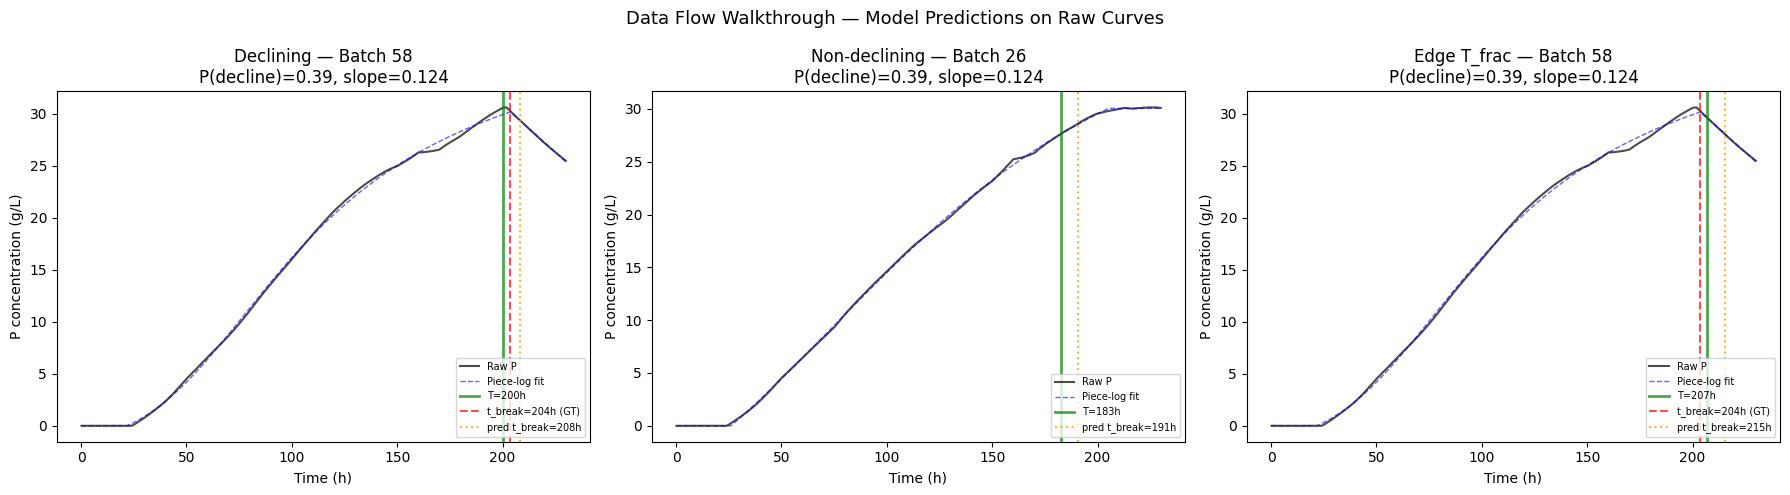

In [11]:
from src.piecelog_model import piecelog_numpy, PARAM_NAMES

# --- Build a fresh model for the walkthrough ---
_seq_len = loaders["max_seq_len"]
_n_feat = loaders["n_features"]
_T_max = np.max([batches[bid]["time"].max() for bid in source_ids])

walk_model = DeclineForecastModel(
    n_features=_n_feat, seq_len=_seq_len, T_max=_T_max,
    d_model=32, n_heads=4, n_layers=2, d_ff=128, head_hidden=32, dropout=0.1,
)
initialize_decline_forecast_head(walk_model, fitted_params_df)
walk_model = walk_model.to(device).eval()

# --- Pick 3 samples: declining, non-declining, edge-case T_frac ---
train_ds = loaders["train_dataset"]

decline_idx, nodecline_idx, edge_idx = None, None, None
for i in range(len(train_ds)):
    s = train_ds.samples[i]
    if decline_idx is None and s["decline_target"] > 0.5:
        decline_idx = i
    if nodecline_idx is None and s["decline_target"] < 0.5:
        nodecline_idx = i
    if edge_idx is None and s["T_frac"] > 0.88:
        edge_idx = i
    if all(x is not None for x in [decline_idx, nodecline_idx, edge_idx]):
        break

sample_indices = [decline_idx or 0, nodecline_idx or 1, edge_idx or 2]
sample_labels = ["Declining", "Non-declining", "Edge T_frac"]

# --- Step-by-step forward pass ---
print("=" * 80)
print("DATA FLOW WALKTHROUGH")
print("=" * 80)

for label, idx in zip(sample_labels, sample_indices):
    s = train_ds[idx]
    meta = train_ds.samples[idx]
    x = s["x"].unsqueeze(0).to(device)         # (1, seq_len, n_ch)
    T_frac = s["T_frac"].unsqueeze(0).to(device)  # (1,)

    print(f"\n--- {label} (sample {idx}, batch {meta['batch_id']}, T_frac={s['T_frac']:.3f}) ---")
    print(f"  Targets: decline={meta['decline_target']:.0f}, "
          f"delta={meta['delta_target']:.4f}, slope={meta['slope_target']:.4f}")

    with torch.no_grad():
        # Step 1: Encoder
        features = walk_model.encoder(x)  # (1, d_model)
        f_np = features.cpu().numpy().flatten()
        print(f"  Encoder features (1, {features.shape[1]}): "
              f"min={f_np.min():.4f}, max={f_np.max():.4f}, mean={f_np.mean():.4f}")

        # Step 2: Shared layer
        T_norm = T_frac.unsqueeze(-1) / walk_model.T_max
        combined = torch.cat([features, T_norm], dim=-1)  # (1, d_model+1)
        h = walk_model.head.shared(combined)               # (1, head_hidden)
        h_np = h.cpu().numpy().flatten()
        print(f"  Shared hidden  (1, {h.shape[1]}): "
              f"min={h_np.min():.4f}, max={h_np.max():.4f}, mean={h_np.mean():.4f}")

        # Step 3: Task heads
        preds = walk_model(x, T_frac)
        print(f"  Predictions: decline_prob={preds['decline_prob'].item():.4f}, "
              f"delta={preds['delta_t_break'].item():.4f}, "
              f"slope={preds['slope'].item():.4f}")

# --- Visual: 1x3 subplot showing raw P curve + model predictions ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, label, idx in zip(axes, sample_labels, sample_indices):
    s = train_ds[idx]
    meta = train_ds.samples[idx]
    bid = meta["batch_id"]
    df = batches[bid]
    row = fitted_params_df[fitted_params_df["batch_id"] == bid].iloc[0]

    # Raw P concentration
    ax.plot(df["time"].values, df["P"].values, "k-", lw=1.5, alpha=0.7, label="Raw P")

    # Ground truth piece-log curve (uses all 7 params)
    params = row[PARAM_NAMES].values.astype(float)
    t_fit = np.linspace(0, df["time"].max(), 500)
    P_fit = piecelog_numpy(t_fit, *params)
    ax.plot(t_fit, P_fit, "b--", lw=1, alpha=0.6, label="Piece-log fit")

    # Cutoff time T
    T_hours = s["T_frac"].item() * df["time"].max()
    ax.axvline(T_hours, color="green", ls="-", lw=2, alpha=0.7, label=f"T={T_hours:.0f}h")

    # Ground truth t_break
    if row["slope"] > GATE_THRESHOLD:
        ax.axvline(row["t_break"], color="red", ls="--", lw=1.5, alpha=0.7,
                    label=f"t_break={row['t_break']:.0f}h (GT)")

    # Model prediction overlay
    x_t = s["x"].unsqueeze(0).to(device)
    tf_t = s["T_frac"].unsqueeze(0).to(device)
    with torch.no_grad():
        preds = walk_model(x_t, tf_t)

    pred_prob = preds["decline_prob"].item()
    pred_delta_h = preds["delta_t_break"].item() * T_MAX_NORM
    pred_slope = preds["slope"].item()
    pred_t_break = T_hours + pred_delta_h

    # Draw predicted decline as annotation
    ax.axvline(pred_t_break, color="orange", ls=":", lw=1.5, alpha=0.8,
               label=f"pred t_break={pred_t_break:.0f}h")

    ax.set_title(f"{label} — Batch {bid}\n"
                 f"P(decline)={pred_prob:.2f}, slope={pred_slope:.3f}")
    ax.set_xlabel("Time (h)")
    ax.set_ylabel("P concentration (g/L)")
    ax.legend(fontsize=7, loc="lower right")

plt.suptitle("Data Flow Walkthrough — Model Predictions on Raw Curves", fontsize=13)
plt.tight_layout()
plt.show()

## 5. Model Setup

In [18]:
seq_len = loaders["max_seq_len"]
n_features = loaders["n_features"]
T_max = np.max([batches[bid]["time"].max() for bid in source_ids])

print(f"seq_len: {seq_len}, n_features: {n_features}, T_max: {T_max:.1f}h")

model = DeclineForecastModel(
    n_features=n_features,
    seq_len=seq_len,
    T_max=T_max,
    d_model=64, #32 good
    n_heads=8,
    n_layers=2,
    d_ff=128,
    head_hidden=32,  #32 good
    dropout=0.1,

    patch_len=8,
    patch_stride=4
    
)

initialize_decline_forecast_head(model, fitted_params_df)

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters: {n_params:,}")

seq_len: 1200, n_features: 28, T_max: 290.0h
Total parameters: 83,683


/Users/aless/Desktop/Projects/IndPenSim_Forecast_UDA/notebooks/../src/transformer_model.py:157: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)


## 6. Training

In [19]:
results = train_and_evaluate_decline(
    model=model,
    train_loader=loaders["train"],
    val_loader=loaders["val"],
    n_epochs=50,
    lr=1e-3,
    lr_min=3e-5,
    weight_decay=1e-4,
    patience=20,
    w_bce=1.0,
    w_delta=1.0,
    w_slope=0.5,
    device=device,
    verbose=True,
    print_every=10,
)

print(f"\nBest epoch: {results['best_epoch']}")
print(f"Val AUC-ROC: {results['val_metrics']['auc_roc']:.3f}")
print(f"Val Accuracy: {results['val_metrics']['accuracy']:.3f}")
print(f"Val Delta MAE: {results['val_metrics']['delta_mae_hours']:.1f}h")

Epoch 10/50 | Train: 0.1521 | Val: 0.0463 | AUC: 1.000 | Acc: 1.000 | ΔT MAE: 18.1h
Epoch 20/50 | Train: 0.0372 | Val: 0.1305 | AUC: 1.000 | Acc: 0.953 | ΔT MAE: 17.9h
Epoch 30/50 | Train: 0.0189 | Val: 0.0372 | AUC: 1.000 | Acc: 0.984 | ΔT MAE: 19.4h
Epoch 40/50 | Train: 0.0153 | Val: 0.0213 | AUC: 1.000 | Acc: 1.000 | ΔT MAE: 18.1h
Epoch 50/50 | Train: 0.0141 | Val: 0.0193 | AUC: 1.000 | Acc: 1.000 | ΔT MAE: 17.7h

Best epoch: 37
Val AUC-ROC: 1.000
Val Accuracy: 1.000
Val Delta MAE: 18.0h


## 7. Training Curves

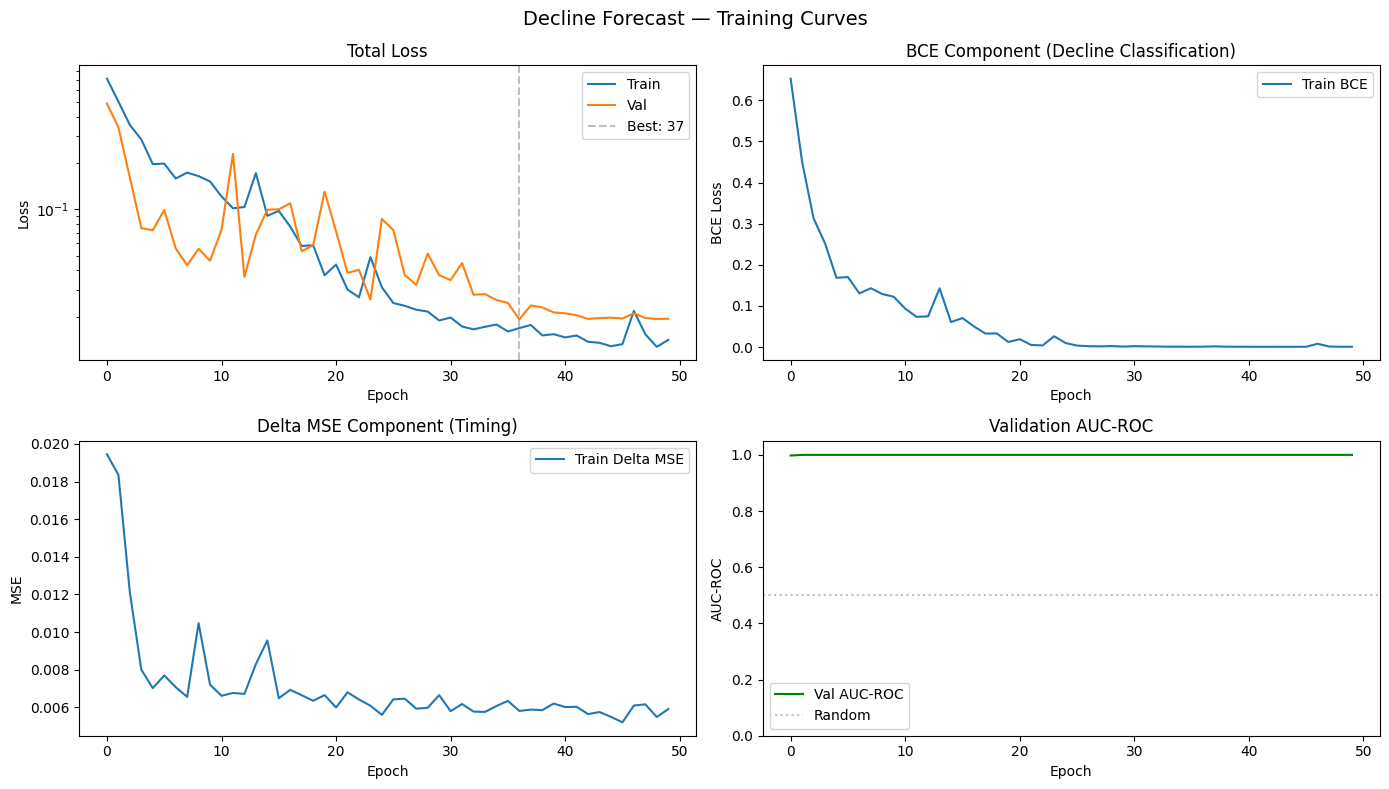

In [20]:
h = results["history"]

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# Total loss
axes[0, 0].semilogy(h["train_loss"], label="Train")
axes[0, 0].semilogy(h["val_loss"], label="Val")
axes[0, 0].axvline(results["best_epoch"] - 1, color="gray", ls="--", alpha=0.5, label=f"Best: {results['best_epoch']}")
axes[0, 0].set_xlabel("Epoch")
axes[0, 0].set_ylabel("Loss")
axes[0, 0].set_title("Total Loss")
axes[0, 0].legend()

# BCE component
axes[0, 1].plot(h["train_bce"], label="Train BCE")
axes[0, 1].set_xlabel("Epoch")
axes[0, 1].set_ylabel("BCE Loss")
axes[0, 1].set_title("BCE Component (Decline Classification)")
axes[0, 1].legend()

# Delta MSE component
axes[1, 0].plot(h["train_delta_mse"], label="Train Delta MSE")
axes[1, 0].set_xlabel("Epoch")
axes[1, 0].set_ylabel("MSE")
axes[1, 0].set_title("Delta MSE Component (Timing)")
axes[1, 0].legend()

# Val AUC-ROC
axes[1, 1].plot(h["val_auc_roc"], color="green", label="Val AUC-ROC")
axes[1, 1].axhline(0.5, color="gray", ls=":", alpha=0.5, label="Random")
axes[1, 1].set_xlabel("Epoch")
axes[1, 1].set_ylabel("AUC-ROC")
axes[1, 1].set_title("Validation AUC-ROC")
axes[1, 1].set_ylim(0, 1.05)
axes[1, 1].legend()

plt.suptitle("Decline Forecast — Training Curves", fontsize=14)
plt.tight_layout()
plt.show()

## 8. Final Metrics Table

In [21]:
model.eval()
model = model.to(device)

splits = [
    ("Train", loaders["train"]),
    ("Val", loaders["val"]),
    ("Target", loaders["target"]),
]

all_metrics = {}
for name, loader in splits:
    _, _, metrics = eval_decline_epoch(model, loader, device)
    all_metrics[name] = metrics

print("=" * 90)
print("Decline Forecast — Final Metrics")
print("=" * 90)
header = f"{'Split':>7s} | {'AUC-ROC':>8s} | {'Acc':>6s} | {'\u0394T MAE':>7s} | {'\u0394T pre':>7s} | {'\u0394T post':>8s} | {'sl dec':>7s} | {'sl nod':>7s}"
print(header)
print("-" * 90)
for name in ["Train", "Val", "Target"]:
    m = all_metrics[name]
    def fmt(v, suffix=""):
        return f"{v:.3f}{suffix}" if not np.isnan(v) else "  n/a"
    print(
        f"{name:>7s} | {fmt(m['auc_roc']):>8s} | {fmt(m['accuracy']):>6s} | "
        f"{m['delta_mae_hours']:>6.1f}h | {fmt(m['delta_mae_pre'], 'h'):>7s} | "
        f"{fmt(m['delta_mae_post'], 'h'):>8s} | {fmt(m['slope_mae_decline']):>7s} | "
        f"{fmt(m['slope_mae_nodecline']):>7s}"
    )
print("=" * 90)

Decline Forecast — Final Metrics
  Split |  AUC-ROC |    Acc |  ΔT MAE |  ΔT pre |  ΔT post |  sl dec |  sl nod
------------------------------------------------------------------------------------------
  Train |    1.000 |  0.999 |   17.8h | 20.672h |  13.961h |   0.011 |   0.127
    Val |    1.000 |  1.000 |   18.2h | 23.183h |  13.955h |   0.013 |   0.125
 Target |      n/a |  0.875 |   19.4h | 19.414h |      n/a |     n/a |   0.131


## 9. ROC Curve (Validation Set)

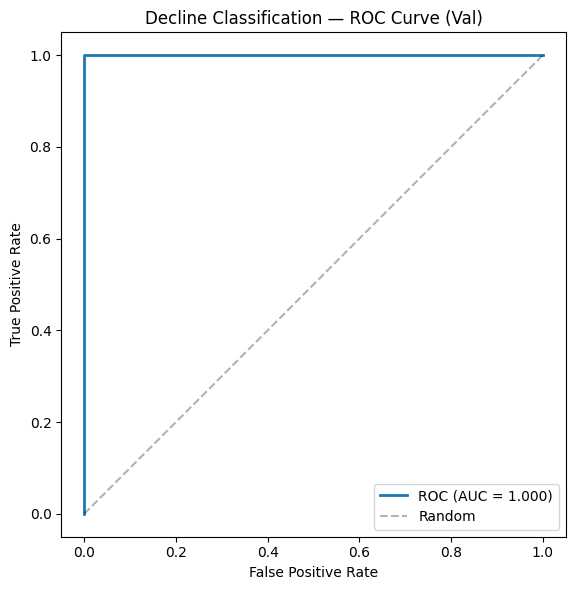

In [22]:
from sklearn.metrics import roc_curve, auc

# Collect val predictions
all_probs, all_targets = [], []
model.eval()
with torch.no_grad():
    for batch in loaders["val"]:
        x = batch["x"].to(device)
        T_frac = batch["T_frac"].to(device)
        preds = model(x, T_frac)
        all_probs.append(preds["decline_prob"].cpu().numpy())
        all_targets.append(batch["decline_target"].numpy())

all_probs = np.concatenate(all_probs)
all_targets = np.concatenate(all_targets)

fpr, tpr, _ = roc_curve(all_targets, all_probs)
roc_auc = auc(fpr, tpr)

fig, ax = plt.subplots(figsize=(6, 6))
ax.plot(fpr, tpr, lw=2, label=f"ROC (AUC = {roc_auc:.3f})")
ax.plot([0, 1], [0, 1], "k--", alpha=0.3, label="Random")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("Decline Classification — ROC Curve (Val)")
ax.legend()
ax.set_aspect("equal")
plt.tight_layout()
plt.show()

## 10. Delta Scatter — Predicted vs True

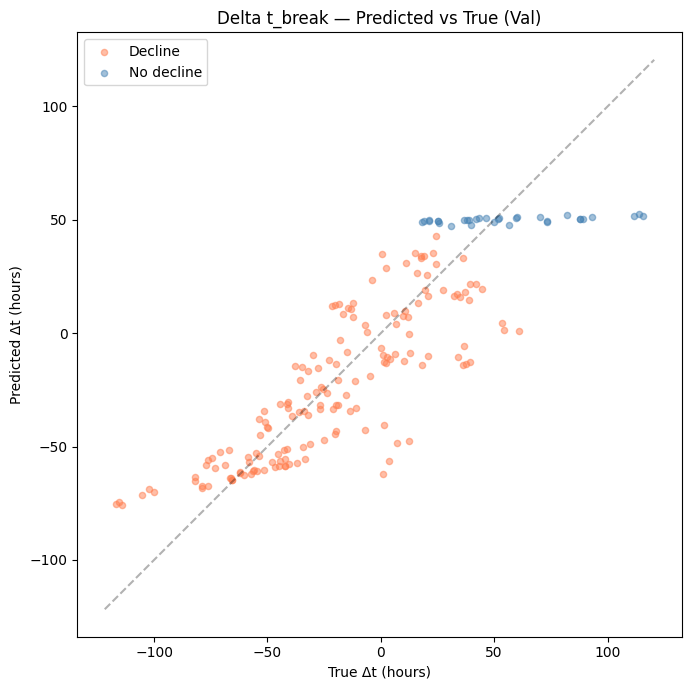

In [23]:
# Collect delta predictions across val set
all_delta_pred, all_delta_true, all_decline_labels = [], [], []
model.eval()
with torch.no_grad():
    for batch in loaders["val"]:
        x = batch["x"].to(device)
        T_frac = batch["T_frac"].to(device)
        preds = model(x, T_frac)
        all_delta_pred.append(preds["delta_t_break"].cpu().numpy())
        all_delta_true.append(batch["delta_target"].numpy())
        all_decline_labels.append(batch["decline_target"].numpy())

all_delta_pred = np.concatenate(all_delta_pred) * T_MAX_NORM  # denormalize to hours
all_delta_true = np.concatenate(all_delta_true) * T_MAX_NORM
all_decline_labels = np.concatenate(all_decline_labels)

pre_mask = all_decline_labels > 0.5
post_mask = ~pre_mask

fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(all_delta_true[pre_mask], all_delta_pred[pre_mask],
           alpha=0.5, s=20, c="coral", label="Decline")
ax.scatter(all_delta_true[post_mask], all_delta_pred[post_mask],
           alpha=0.5, s=20, c="steelblue", label="No decline")

lims = [
    min(all_delta_true.min(), all_delta_pred.min()) - 5,
    max(all_delta_true.max(), all_delta_pred.max()) + 5,
]
ax.plot(lims, lims, "k--", alpha=0.3)
ax.set_xlabel("True \u0394t (hours)")
ax.set_ylabel("Predicted \u0394t (hours)")
ax.set_title("Delta t_break — Predicted vs True (Val)")
ax.legend()
ax.set_aspect("equal")
plt.tight_layout()
plt.show()

## 11. Slope Scatter — Declining Batches Only

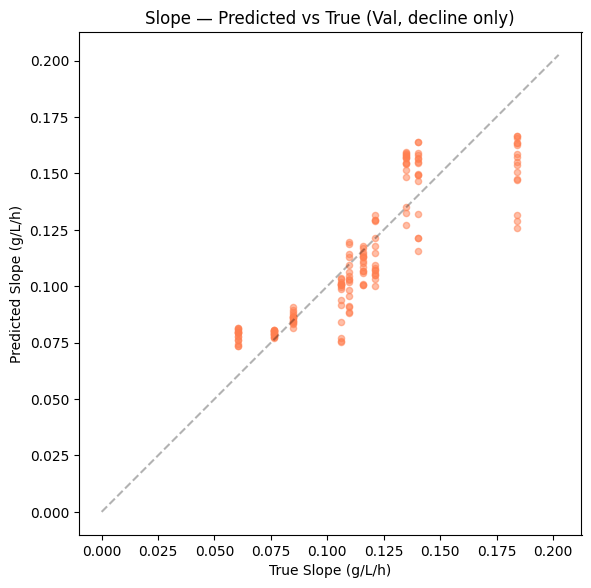

In [24]:
# Collect slope predictions across val set
all_slope_pred, all_slope_true, all_decline_labels2 = [], [], []
model.eval()
with torch.no_grad():
    for batch in loaders["val"]:
        x = batch["x"].to(device)
        T_frac = batch["T_frac"].to(device)
        preds = model(x, T_frac)
        all_slope_pred.append(preds["slope"].cpu().numpy())
        all_slope_true.append(batch["slope_target"].numpy())
        all_decline_labels2.append(batch["decline_target"].numpy())

all_slope_pred = np.concatenate(all_slope_pred)
all_slope_true = np.concatenate(all_slope_true)
all_decline_labels2 = np.concatenate(all_decline_labels2)

decline_mask = all_decline_labels2 > 0.5

if decline_mask.any():
    fig, ax = plt.subplots(figsize=(6, 6))
    ax.scatter(all_slope_true[decline_mask], all_slope_pred[decline_mask],
               alpha=0.5, s=20, c="coral")
    lims = [
        0,
        max(all_slope_true[decline_mask].max(), all_slope_pred[decline_mask].max()) * 1.1,
    ]
    ax.plot(lims, lims, "k--", alpha=0.3)
    ax.set_xlabel("True Slope (g/L/h)")
    ax.set_ylabel("Predicted Slope (g/L/h)")
    ax.set_title("Slope — Predicted vs True (Val, decline only)")
    ax.set_aspect("equal")
    plt.tight_layout()
    plt.show()
else:
    print("No declining batches in validation set.")

## 12. Per-Batch Decline Probability vs Observation Window

For 6 batches (3 declining, 3 non-declining), sweep T_frac from 0.4 to 0.9 and
plot how `decline_prob` evolves as more of the batch is observed.

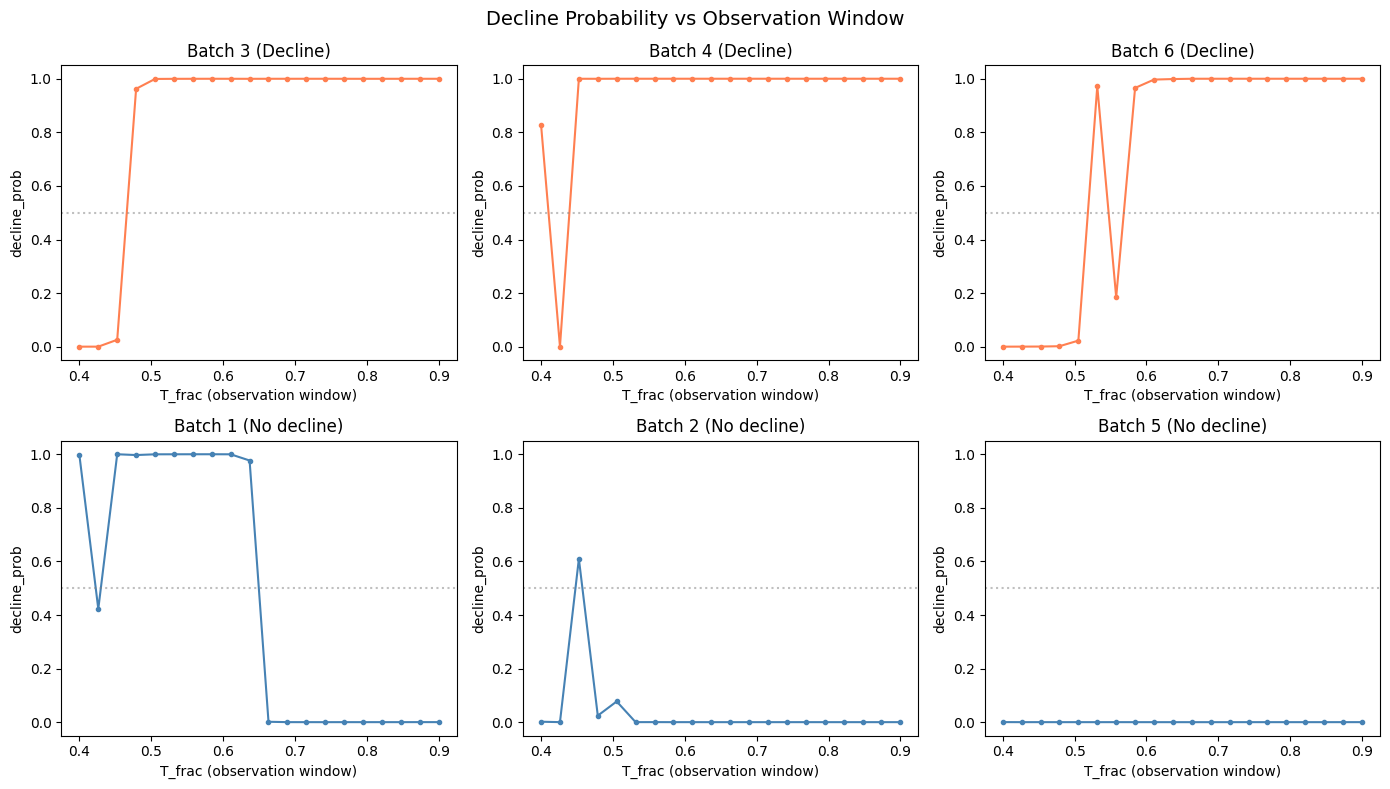

In [25]:
from src.preprocessing import (
    compute_normalization_stats_expanded,
    preprocess_expanded_features,
    normalize_features_expanded,
)
from src.tft_dataset import build_concentration_channels
from src.feature_config import INPUT_FEATURES_EXPANDED

# Pick 3 declining + 3 non-declining source batches
src_params = fitted_params_df[fitted_params_df["batch_id"].isin(source_ids)]
decline_bids = src_params[src_params["has_decline"]]["batch_id"].tolist()[:3]
nodecline_bids = src_params[~src_params["has_decline"]]["batch_id"].tolist()[:3]
plot_bids = decline_bids + nodecline_bids

stats = loaders["stats"]
features = list(INPUT_FEATURES_EXPANDED)

# Concentration stats from train dataset
train_ds = loaders["train_dataset"]
conc_mean = train_ds.conc_mean
conc_std = train_ds.conc_std
ts_mean = train_ds.time_since_mean
ts_std = train_ds.time_since_std

T_fracs = np.linspace(0.4, 0.9, 20)
max_seq_len = loaders["max_seq_len"]

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
model.eval()

for ax, bid in zip(axes.flat, plot_bids):
    df = batches[bid]
    n_steps = len(df)
    row = fitted_params_df[fitted_params_df["batch_id"] == bid].iloc[0]
    has_decline = row["slope"] > GATE_THRESHOLD

    probs = []
    for tf in T_fracs:
        T_idx = max(10, min(int(tf * n_steps), n_steps - 1))
        input_df = df.iloc[:T_idx].copy()

        processed = preprocess_expanded_features(input_df, features)
        X_feat = normalize_features_expanded(processed, stats)

        conc_ffill, conc_mask, conc_time_since = build_concentration_channels(input_df, "P")
        conc_ffill_norm = (conc_ffill - conc_mean) / conc_std
        conc_time_norm = (conc_time_since - ts_mean) / ts_std

        X = np.concatenate([
            X_feat,
            conc_ffill_norm[:, None],
            conc_mask[:, None],
            conc_time_norm[:, None],
        ], axis=1)

        T_actual = X.shape[0]
        if T_actual > max_seq_len:
            X = X[T_actual - max_seq_len:]
        elif T_actual < max_seq_len:
            pad = np.zeros((max_seq_len - T_actual, X.shape[1]))
            X = np.concatenate([pad, X], axis=0)

        x_t = torch.tensor(X, dtype=torch.float32).unsqueeze(0).to(device)
        tf_t = torch.tensor([T_idx / n_steps], dtype=torch.float32).to(device)

        with torch.no_grad():
            pred = model(x_t, tf_t)
        probs.append(pred["decline_prob"].cpu().item())

    color = "coral" if has_decline else "steelblue"
    label = "Decline" if has_decline else "No decline"
    ax.plot(T_fracs, probs, "-o", color=color, markersize=3, lw=1.5)
    ax.axhline(0.5, color="gray", ls=":", alpha=0.5)
    ax.set_xlabel("T_frac (observation window)")
    ax.set_ylabel("decline_prob")
    ax.set_title(f"Batch {bid} ({label})")
    ax.set_ylim(-0.05, 1.05)

plt.suptitle("Decline Probability vs Observation Window", fontsize=14)
plt.tight_layout()
plt.show()

## 13. Feature & Patch Importance via Gradient Saliency

Use input-gradient saliency to understand what drives high `decline_prob`:
- **Feature importance**: mean |d(decline_prob)/dx| per channel, aggregated across samples
- **Patch temporal saliency**: mean |grad| per patch position — do recent patches matter more?
- **Per-sample saliency heatmaps**: (time x channel) maps for individual high-confidence declining samples

In [26]:
from src.feature_config import INPUT_FEATURES_EXPANDED

feature_names = list(INPUT_FEATURES_EXPANDED) + ["P_ffill", "P_mask", "P_time_since"]

# --- Collect gradient saliency across all train samples ---
# Since model uses LayerNorm (per-sample), batch gradients are independent:
# d(sum_i prob_i) / d(x_i) == d(prob_i) / d(x_i) for each sample i.
all_grads = []
all_decline_labels_g = []
all_probs_grad = []

model.eval()
for batch in loaders["train"]:
    x = batch["x"].to(device).requires_grad_(True)
    T_frac = batch["T_frac"].to(device)

    preds = model(x, T_frac)
    preds["decline_prob"].sum().backward()

    all_grads.append(x.grad.detach().cpu().numpy())
    all_decline_labels_g.append(batch["decline_target"].numpy())
    all_probs_grad.append(preds["decline_prob"].detach().cpu().numpy())
    model.zero_grad()

all_grads = np.concatenate(all_grads)                  # (N, seq_len, 28)
all_decline_labels_g = np.concatenate(all_decline_labels_g)
all_probs_grad = np.concatenate(all_probs_grad)

decline_mask_g = all_decline_labels_g > 0.5
nodecline_mask_g = ~decline_mask_g

print(f"Collected gradients: {all_grads.shape}")
print(f"  Decline samples: {decline_mask_g.sum()}, No-decline: {nodecline_mask_g.sum()}")
print(f"  Mean |grad| (decline):    {np.abs(all_grads[decline_mask_g]).mean():.6f}")
print(f"  Mean |grad| (no-decline): {np.abs(all_grads[nodecline_mask_g]).mean():.6f}")

Collected gradients: (768, 1200, 28)
  Decline samples: 599, No-decline: 169
  Mean |grad| (decline):    0.000001
  Mean |grad| (no-decline): 0.000002


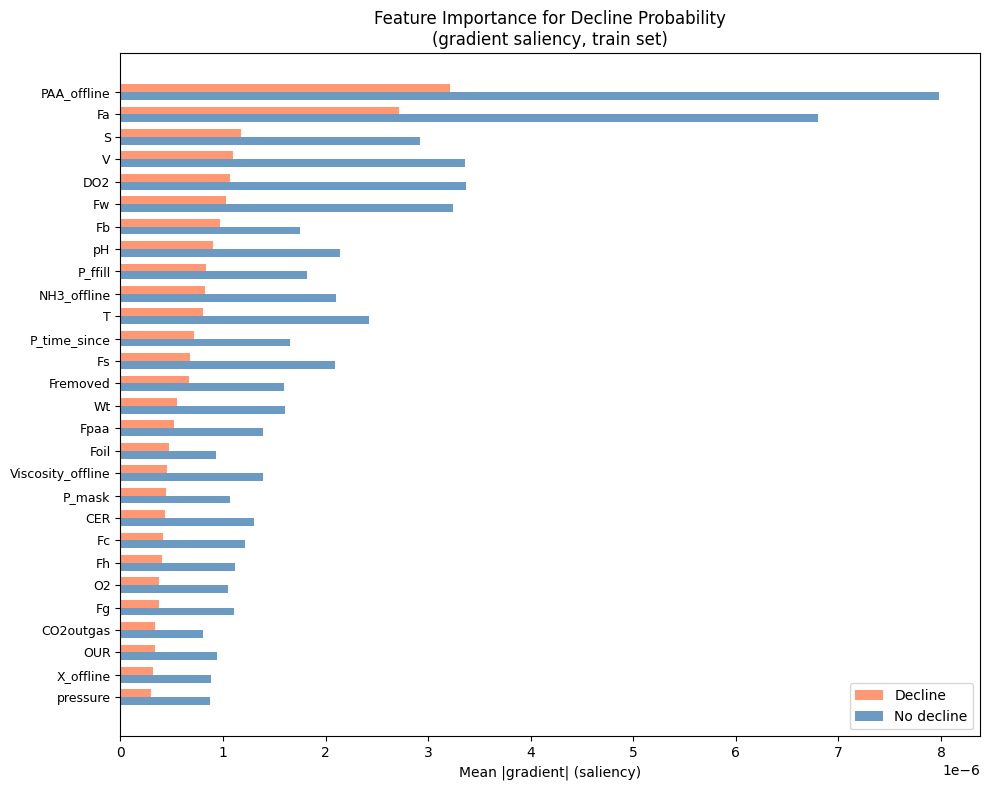

Top 10 features driving decline_prob (declining batches):
   1. PAA_offline                |grad|=0.000003  (ratio vs no-decline: 0.40x)
   2. Fa                         |grad|=0.000003  (ratio vs no-decline: 0.40x)
   3. S                          |grad|=0.000001  (ratio vs no-decline: 0.40x)
   4. V                          |grad|=0.000001  (ratio vs no-decline: 0.33x)
   5. DO2                        |grad|=0.000001  (ratio vs no-decline: 0.32x)
   6. Fw                         |grad|=0.000001  (ratio vs no-decline: 0.32x)
   7. Fb                         |grad|=0.000001  (ratio vs no-decline: 0.56x)
   8. pH                         |grad|=0.000001  (ratio vs no-decline: 0.42x)
   9. P_ffill                    |grad|=0.000001  (ratio vs no-decline: 0.46x)
  10. NH3_offline                |grad|=0.000001  (ratio vs no-decline: 0.39x)


In [27]:
# --- Feature importance: decline vs no-decline ---
feat_imp_decline = np.abs(all_grads[decline_mask_g]).mean(axis=(0, 1))      # (28,)
feat_imp_nodecline = np.abs(all_grads[nodecline_mask_g]).mean(axis=(0, 1))  # (28,)

sort_idx = np.argsort(feat_imp_decline)

fig, ax = plt.subplots(figsize=(10, 8))
y_pos = np.arange(len(feature_names))
bar_h = 0.35

ax.barh(y_pos + bar_h/2, feat_imp_decline[sort_idx], bar_h,
        color="coral", alpha=0.8, label="Decline")
ax.barh(y_pos - bar_h/2, feat_imp_nodecline[sort_idx], bar_h,
        color="steelblue", alpha=0.8, label="No decline")

ax.set_yticks(y_pos)
ax.set_yticklabels([feature_names[i] for i in sort_idx], fontsize=9)
ax.set_xlabel("Mean |gradient| (saliency)")
ax.set_title("Feature Importance for Decline Probability\n(gradient saliency, train set)")
ax.legend()
plt.tight_layout()
plt.show()

# Top 10 features
print("Top 10 features driving decline_prob (declining batches):")
for rank, idx in enumerate(sort_idx[::-1][:10], 1):
    ratio = feat_imp_decline[idx] / (feat_imp_nodecline[idx] + 1e-10)
    print(f"  {rank:2d}. {feature_names[idx]:<25s}  "
          f"|grad|={feat_imp_decline[idx]:.6f}  (ratio vs no-decline: {ratio:.2f}x)")

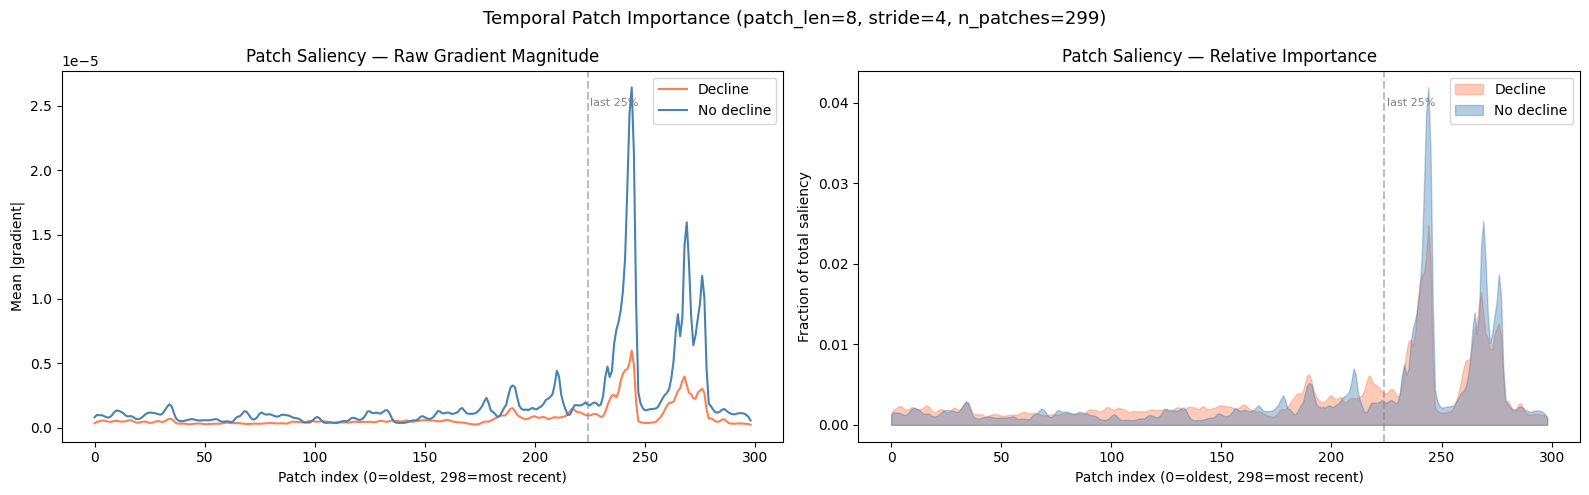

Saliency in last 25% of patches:
  Decline:    51.1% (uniform would be 25%)
  No-decline: 62.0%


In [28]:
# --- Patch temporal saliency — do recent patches matter more? ---
patch_len = model.encoder.patch_embed.patch_len
patch_stride = model.encoder.patch_embed.patch_stride
n_patches = model.encoder.n_patches

# Mean |grad| over channels → temporal saliency per timestep
decline_temporal = np.abs(all_grads[decline_mask_g]).mean(axis=2)     # (N_dec, seq_len)
nodecline_temporal = np.abs(all_grads[nodecline_mask_g]).mean(axis=2)

# Bin into patch-aligned windows
patch_sal_decline = np.zeros(n_patches)
patch_sal_nodecline = np.zeros(n_patches)
for j in range(n_patches):
    t0 = j * patch_stride
    t1 = t0 + patch_len
    patch_sal_decline[j] = decline_temporal[:, t0:t1].mean()
    patch_sal_nodecline[j] = nodecline_temporal[:, t0:t1].mean()

# Normalize to fraction of total
patch_frac_dec = patch_sal_decline / patch_sal_decline.sum()
patch_frac_nod = patch_sal_nodecline / patch_sal_nodecline.sum()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

ax = axes[0]
ax.plot(range(n_patches), patch_sal_decline, color="coral", lw=1.5, label="Decline")
ax.plot(range(n_patches), patch_sal_nodecline, color="steelblue", lw=1.5, label="No decline")
ax.set_xlabel(f"Patch index (0=oldest, {n_patches-1}=most recent)")
ax.set_ylabel("Mean |gradient|")
ax.set_title("Patch Saliency — Raw Gradient Magnitude")
ax.legend()

ax = axes[1]
ax.fill_between(range(n_patches), patch_frac_dec, alpha=0.4, color="coral", label="Decline")
ax.fill_between(range(n_patches), patch_frac_nod, alpha=0.4, color="steelblue", label="No decline")
ax.set_xlabel(f"Patch index (0=oldest, {n_patches-1}=most recent)")
ax.set_ylabel("Fraction of total saliency")
ax.set_title("Patch Saliency — Relative Importance")
ax.legend()

cutoff = int(0.75 * n_patches)
for a in axes:
    a.axvline(cutoff, color="gray", ls="--", alpha=0.5)
    a.text(cutoff + 1, a.get_ylim()[1] * 0.9, "last 25%", fontsize=8, color="gray")

plt.suptitle(f"Temporal Patch Importance (patch_len={patch_len}, stride={patch_stride}, "
             f"n_patches={n_patches})", fontsize=13)
plt.tight_layout()
plt.show()

last_q_dec = patch_frac_dec[cutoff:].sum()
last_q_nod = patch_frac_nod[cutoff:].sum()
print(f"Saliency in last 25% of patches:")
print(f"  Decline:    {last_q_dec:.1%} (uniform would be 25%)")
print(f"  No-decline: {last_q_nod:.1%}")

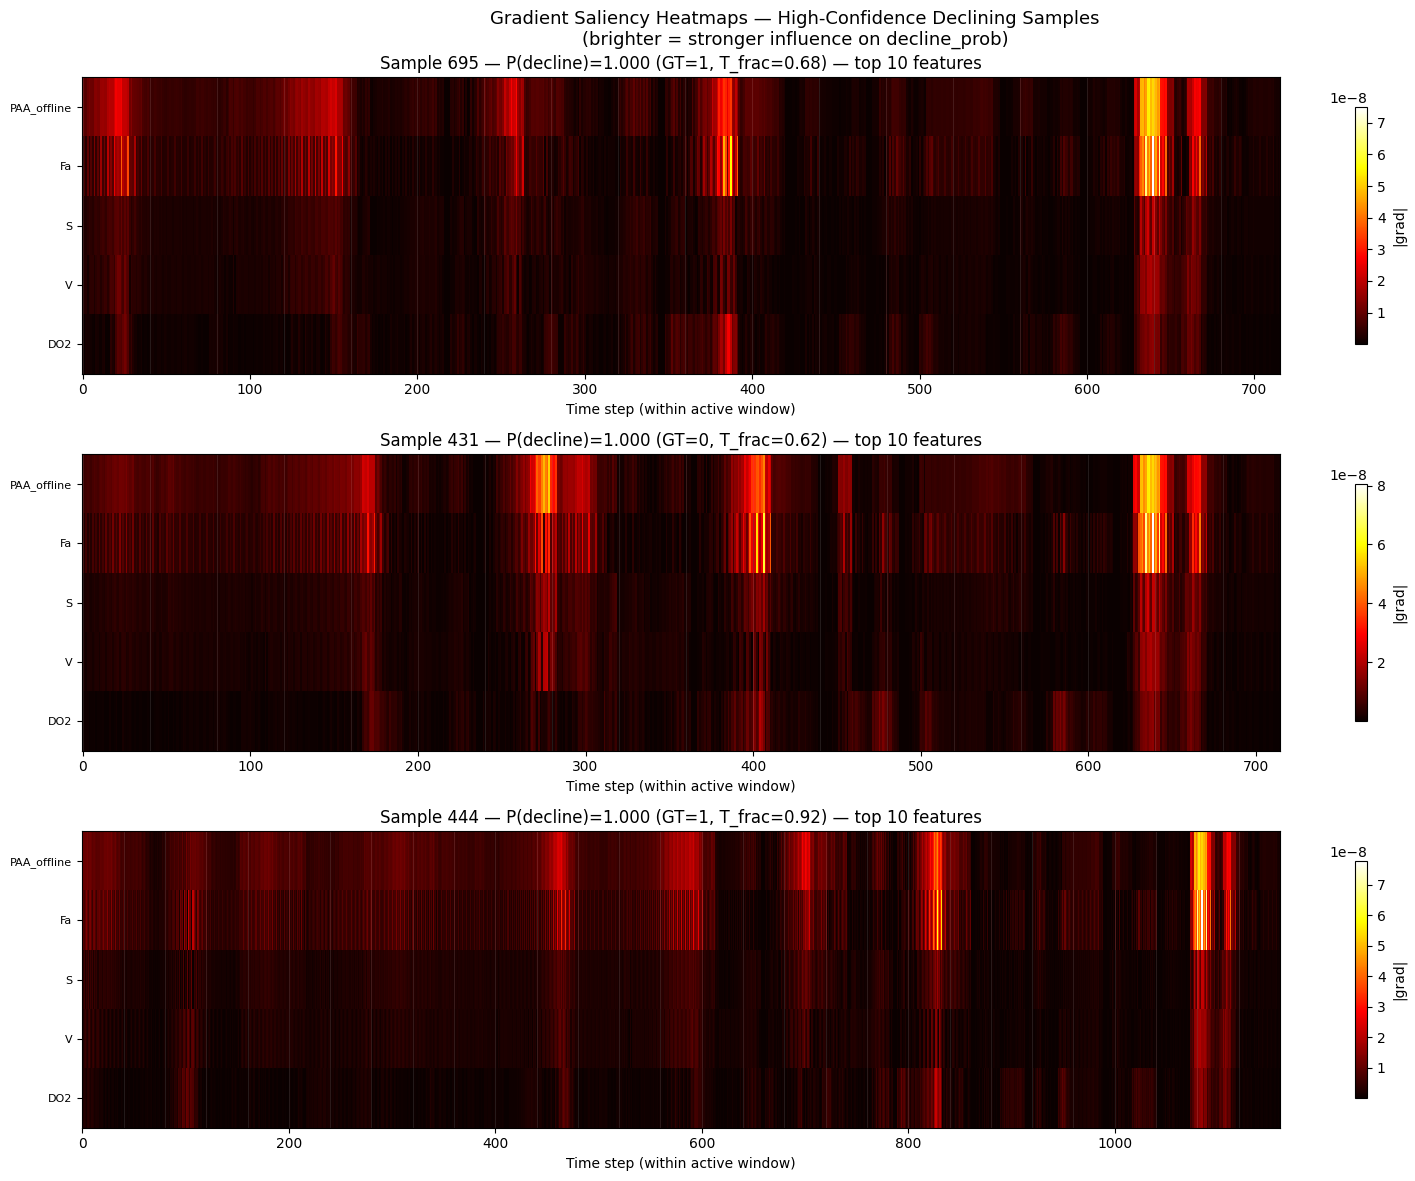

In [29]:
# --- Per-sample saliency heatmaps for 3 high-confidence declining samples ---
decline_indices_g = np.where(decline_mask_g)[0]
top3_by_prob = decline_indices_g[np.argsort(all_probs_grad[decline_indices_g])[::-1][:3]]

# Re-collect input tensors for these samples by iterating through the dataloader
top3_data = {}
idx_counter = 0
for batch in loaders["train"]:
    B = batch["x"].shape[0]
    for b in range(B):
        if idx_counter in top3_by_prob:
            top3_data[idx_counter] = {
                "x": batch["x"][b],
                "T_frac": batch["T_frac"][b].item(),
                "decline_target": batch["decline_target"][b].item(),
            }
        idx_counter += 1
    if len(top3_data) == 3:
        break

# Top-5 features by importance for readability
top_idx = np.argsort(feat_imp_decline)[::-1][:5]
top_names = [feature_names[i] for i in top_idx]

fig, axes = plt.subplots(3, 1, figsize=(16, 12))

for ax, g_idx in zip(axes, top3_by_prob):
    grad_abs = np.abs(all_grads[g_idx])  # (seq_len, 28)
    x_np = top3_data[g_idx]["x"].numpy()

    # Crop to non-padded region
    active_mask = np.abs(x_np).sum(axis=1) > 0
    first_active = int(np.argmax(active_mask)) if active_mask.any() else 0
    grad_crop = grad_abs[first_active:]

    # Select top-10 features
    grad_top10 = grad_crop[:, top_idx]

    im = ax.imshow(grad_top10.T, aspect="auto", cmap="hot", interpolation="nearest")
    ax.set_yticks(range(len(top_names)))
    ax.set_yticklabels(top_names, fontsize=8)
    ax.set_xlabel("Time step (within active window)")
    ax.set_title(f"Sample {g_idx} — P(decline)={all_probs_grad[g_idx]:.3f} "
                 f"(GT={top3_data[g_idx]['decline_target']:.0f}, "
                 f"T_frac={top3_data[g_idx]['T_frac']:.2f}) — top 10 features")
    plt.colorbar(im, ax=ax, label="|grad|", shrink=0.8)

    # Mark every 10th patch boundary for orientation
    for j in range(0, grad_crop.shape[0], patch_stride * 10):
        ax.axvline(j, color="white", alpha=0.15, lw=0.5)

plt.suptitle("Gradient Saliency Heatmaps — High-Confidence Declining Samples\n"
             "(brighter = stronger influence on decline_prob)", fontsize=13)
plt.tight_layout()
plt.show()